## Andmete uuriv analüüs (EDA) ja puhastamine

Selles märkmikus viime läbi andmete uuriva analüüsi (Exploratory Data Analysis). 
Eesmärk on:
1. Saada ülevaade andmestiku struktuurist ja puuduvatest väärtustest.
2. Eemaldada ebavajalikud või liiga lünklikud tunnused (näiteks konsolideeritud näitajad).
3. Täita puuduvad numbrilised väärtused loogiliselt (enamasti nullidega, kui finantsnäitaja puudub).
4. Valmistada andmed ette masinõppemudelite treenimiseks.

In [ ]:
import pandas as pd

# Seadistab Pandase nii, et kuvataks piiramatu arv tulpasid
pd.set_option('display.max_columns', None)

# Loeme sisse andmed
df = pd.read_parquet("data/merged_reports.parquet")

In [ ]:
# Saame ülevaate esialgsest tabelist
df.head(10)

,report_id,Assets,AssetsConsolidated,AverageNumberOfEmployeesInFullTimeEquivalentUnits,AverageNumberOfEmployeesInFullTimeEquivalentUnitsConsolidated,BusinessIncome,CashAndCashEquivalents,CashAndCashEquivalentsConsolidated,CurrentAssets,CurrentAssetsConsolidated,CurrentLiabilities,CurrentLiabilitiesConsolidated,DepreciationAndImpairmentLossReversal,DepreciationAndImpairmentLossReversalConsolidated,DepreciationAndImpairmentLossReversalNeg,DepreciationAndImpairmentLossReversalNegConsolidated,EmployeeExpense,EmployeeExpenseConsolidated,Equity,EquityConsolidated,IssuedCapital,IssuedCapital2,IssuedCapital2Consolidated,IssuedCapitalConsolidated,LaborExpense,LaborExpenseConsolidated,LiabilitiesAndNetAssets,NetAssets,NetSurplusDeficitForPeriod,NonCurrentAssets,NonCurrentAssetsConsolidated,NonCurrentLiabilities,NonCurrentLiabilitiesConsolidated,RetainedEarningsLoss,RetainedEarningsLossConsolidated,Revenue,RevenueConsolidated,ServiceFeeIncome,ServiceFeeIncomeConsolidated,SurplusDeficitFromOperatingActivities,TotalAnnualPeriodProfitLoss,TotalAnnualPeriodProfitLossConsolidated,TotalProfitLoss,TotalProfitLossBeforeTax,TotalProfitLossBeforeTaxConsolidated,TotalProfitLossConsolidated,TotalRevenue,registrikood,aruandeaasta,õiguslik vorm,staatus,kas auditeeritud?,minimaalne kategooria andmete alusel
0,994318,946.0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,-480.0,NaN,NaN,NaN,NaN,NaN,946.0,NaN,2600.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,946.0,NaN,NaN,NaN,-471.0,NaN,0.0,NaN,NaN,NaN,NaN,-480.0,NaN,-480.0,-480.0,NaN,NaN,NaN,12755399,2019,OÜ,Kustutatud,Ei,Mikroettevõtja
1,1262635,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2500.0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,14015206,2021,OÜ,Kustutatud,Ei,Väikeettevõtja
2,1434010,2370.0,NaN,NaN,NaN,NaN,2370.0,NaN,2370.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2370.0,NaN,2556.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-186.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,11977548,2019,OÜ,Kustutatud,Ei,Väikeettevõtja
3,1434860,2560.0,NaN,0.0,NaN,NaN,2560.0,NaN,2560.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,2560.0,NaN,2560.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,10011855,2019,TÜH,Kustutatud,Ei,Väikeettevõtja
4,1435129,4.0,NaN,0.0,NaN,NaN,NaN,NaN,4.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,2500.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,-150.0,NaN,0.0,0.0,NaN,NaN,NaN,12546974,2019,OÜ,Kustutatud,Ei,Mikroettevõtja
5,1437324,25983.0,NaN,NaN,NaN,NaN,2424.0,NaN,25983.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25983.0,NaN,16623.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7191.0,NaN,NaN,NaN,NaN,NaN,NaN,-1131.0,NaN,NaN,NaN,NaN,NaN,NaN,10122572,2019,OÜ,Kustutatud,Ei,Väikeettevõtja
6,1440974,3244.0,NaN,0.0,NaN,NaN,2500.0,NaN,3244.0,NaN,693.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2551.0,NaN,2500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,744.0,NaN,NaN,NaN,NaN,NaN,NaN,-693.0,NaN,0.0,0.0,NaN,NaN,NaN,12044439,2019,OÜ,Kustutatud,Ei,Väikeettevõtja
7,1445196,2812.0,NaN,0.0,NaN,NaN,2805.0,NaN,2812.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2812.0,NaN,2556.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,10089030,2019,OÜ,Kustutatud,Ei,Väikeettevõtja
8,1447307,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,12385175,2019,UÜ,Kustutatud,Ei,Väikeettevõtja
9,1447850,28329.0,NaN,NaN,NaN,NaN,28329.0,NaN,28329.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28329.0,NaN,25346.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3025.0,NaN,NaN,NaN,NaN,NaN,NaN,-42.0,NaN,NaN,NaN,NaN,NaN,NaN,10029364,2019,OÜ,Kustutatud,Ei,Väikeettevõtja


In [ ]:
# Vaatame üldist infot
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1439777 entries, 0 to 1439776
Data columns (total 53 columns):
 #   Column                                                         Non-Null Count    Dtype  
---  ------                                                         --------------    -----  
 0   report_id                                                      1439777 non-null  int64  
 1   Assets                                                         1426025 non-null  float64
 2   AssetsConsolidated                                             5280 non-null     float64
 3   AverageNumberOfEmployeesInFullTimeEquivalentUnits              1426965 non-null  float64
 4   AverageNumberOfEmployeesInFullTimeEquivalentUnitsConsolidated  5280 non-null     float64
 5   BusinessIncome                                                 75526 non-null    float64
 6   CashAndCashEquivalents                                         1018791 non-null  float64
 7   CashAndCashEquivalentsConsolidated  

In [ ]:
# Vaatame statistilist infot
df.describe()

,report_id,Assets,AssetsConsolidated,AverageNumberOfEmployeesInFullTimeEquivalentUnits,AverageNumberOfEmployeesInFullTimeEquivalentUnitsConsolidated,BusinessIncome,CashAndCashEquivalents,CashAndCashEquivalentsConsolidated,CurrentAssets,CurrentAssetsConsolidated,CurrentLiabilities,CurrentLiabilitiesConsolidated,DepreciationAndImpairmentLossReversal,DepreciationAndImpairmentLossReversalConsolidated,DepreciationAndImpairmentLossReversalNeg,DepreciationAndImpairmentLossReversalNegConsolidated,EmployeeExpense,EmployeeExpenseConsolidated,Equity,EquityConsolidated,IssuedCapital,IssuedCapital2,IssuedCapital2Consolidated,IssuedCapitalConsolidated,LaborExpense,LaborExpenseConsolidated,LiabilitiesAndNetAssets,NetAssets,NetSurplusDeficitForPeriod,NonCurrentAssets,NonCurrentAssetsConsolidated,NonCurrentLiabilities,NonCurrentLiabilitiesConsolidated,RetainedEarningsLoss,RetainedEarningsLossConsolidated,Revenue,RevenueConsolidated,ServiceFeeIncome,ServiceFeeIncomeConsolidated,SurplusDeficitFromOperatingActivities,TotalAnnualPeriodProfitLoss,TotalAnnualPeriodProfitLossConsolidated,TotalProfitLoss,TotalProfitLossBeforeTax,TotalProfitLossBeforeTaxConsolidated,TotalProfitLossConsolidated,TotalRevenue,registrikood,aruandeaasta
count,1.439777e+06,1.426025e+06,5.280000e+03,1.426965e+06,5280.000000,7.552600e+04,1.018791e+06,5.276000e+03,1.411973e+06,5.280000e+03,1.176871e+06,5.262000e+03,6.325910e+05,4.074000e+03,3.994100e+04,4.889000e+03,7.330230e+05,4.054000e+03,1.221210e+06,5.280000e+03,1.220075e+06,1.218900e+04,1.420000e+03,3.852000e+03,1.316075e+06,5.199000e+03,2.021570e+05,1.997190e+05,2.022230e+05,8.819240e+05,5.240000e+03,5.033720e+05,4.587000e+03,1.101738e+06,5.226000e+03,1.142318e+06,5.191000e+03,2.410000e+02,2.500000e+01,2.015120e+05,1.227764e+06,5.280000e+03,1.211730e+06,1.214709e+06,5.280000e+03,5.277000e+03,1.994040e+05,1.439777e+06,1.439777e+06
mean,2.554578e+06,4.797802e+05,3.109952e+07,1.861695e+00,112.745644,5.592743e+04,7.454963e+04,2.692256e+06,1.944800e+05,1.286167e+07,1.262006e+05,7.072869e+06,-2.175409e+04,-7.846322e+05,2.373193e+05,8.545673e+05,-7.947994e+04,-3.165498e+06,3.217056e+05,1.724673e+07,1.344359e+04,9.839032e+05,2.163478e+06,6.023455e+05,2.744804e+04,1.573199e+06,9.095738e+04,4.665038e+04,2.482823e+03,4.643860e+05,1.837708e+07,2.650862e+05,7.831988e+06,2.346274e+05,1.154681e+07,4.154832e+05,2.530982e+07,1.802675e+05,2.016720e+06,2.731483e+03,3.665996e+04,2.095153e+06,2.817679e+04,3.914693e+04,2.224150e+06,2.067827e+06,6.333623e+04,2.307456e+07,2.021688e+03
std,5.099236e+05,7.312989e+06,8.210826e+07,1.879760e+01,261.663054,1.014790e+06,1.447727e+06,7.727825e+06,3.224439e+06,5.974248e+07,2.920909e+06,2.283518e+07,9.892712e+05,1.891393e+06,3.953995e+06,2.167046e+06,7.588067e+05,5.795171e+06,5.607432e+06,6.055581e+07,1.055245e+06,1.170050e+07,2.532299e+07,1.527707e+07,5.959944e+05,7.682172e+06,1.891548e+06,1.039977e+06,1.320444e+05,7.185178e+06,4.501429e+07,3.217000e+06,2.187866e+07,4.413554e+06,3.499412e+07,5.869193e+06,5.607062e+07,4.825208e+05,2.633988e+06,1.316294e+05,1.739201e+06,1.699185e+07,6.729018e+05,1.755604e+06,1.707403e+07,1.658715e+07,9.301705e+05,2.374045e+07,1.747173e+00
min,9.943180e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,-1.175460e+05,-1.010150e+05,0.000000e+00,-2.704060e+05,0.000000e+00,-5.038876e+06,-3.425000e+03,-6.989870e+08,-3.104442e+07,-2.538025e+06,-2.083000e+06,-9.885401e+07,-7.640725e+07,-9.217200e+07,-4.355798e+07,-2.500000e+03,2.500000e+04,2.500000e+04,1.000000e+00,-7.208398e+07,-6.759748e+07,0.000000e+00,-2.725354e+06,-1.625258e+07,-5.631000e+03,0.000000e+00,-1.385010e+05,0.000000e+00,-1.289820e+08,-7.386260e+07,-4.728750e+05,0.000000e+00,0.000000e+00,1.464600e+04,-1.664146e+07,-5.604524e+08,-8.517704e+07,-3.735110e+08,-5.591889e+08,-8.476795e+07,-8.480798e+07,-1.092190e+05,1.000002e+07,2.019000e+03
25%,2.122745e+06,3.307000e+03,4.175146e+06,0.000000e+00,8.000000,0.000000e+00,1.252000e+03,1.757932e+05,2.564000e+03,1.277418e+06,1.860000e+02,6.313250e+05,-5.215000e+03,-7.269438e+

In [6]:
# Vaatame puuduvate andmete osakaalu
missing_percentages = df.isnull().mean() * 100
missing_percentages.sort_values(ascending=False).head(10)

ServiceFeeIncomeConsolidated                            99.998264
ServiceFeeIncome                                        99.983261
IssuedCapital2Consolidated                              99.901374
IssuedCapitalConsolidated                               99.732459
EmployeeExpenseConsolidated                             99.718429
DepreciationAndImpairmentLossReversalConsolidated       99.717040
NonCurrentLiabilitiesConsolidated                       99.681409
DepreciationAndImpairmentLossReversalNegConsolidated    99.660434
RevenueConsolidated                                     99.639458
LaborExpenseConsolidated                                99.638902
dtype: float64

In [7]:
# 1. Eemaldame kõik 'Consolidated' (konsolideeritud) veerud. 
# Enamik Eesti ettevõtteid on väikesed ja ei esita konsolideeritud aruandeid (99% NaN).
cols_to_drop = [c for c in df.columns if 'Consolidated' in c]
df_cleaned = df.drop(columns=cols_to_drop)
print(f"Eemaldati {len(cols_to_drop)} konsolideeritud veergu.")

Eemaldati 20 konsolideeritud veergu.


In [8]:
# 2. Jätame alles vaid need veerud, kus on vähemalt 75% andmetest olemas (ehk max 25% on NaN)
threshold = 0.75
df_cleaned = df_cleaned.dropna(thresh=int(threshold * len(df_cleaned)), axis=1)

print(f"Pärast 75% reegli rakendamist jäi alles {df_cleaned.shape[1]} veergu.")
print(df_cleaned.columns.tolist())

Pärast 75% reegli rakendamist jäi alles 19 veergu.
['report_id', 'Assets', 'AverageNumberOfEmployeesInFullTimeEquivalentUnits', 'CurrentAssets', 'CurrentLiabilities', 'Equity', 'IssuedCapital', 'LaborExpense', 'RetainedEarningsLoss', 'Revenue', 'TotalAnnualPeriodProfitLoss', 'TotalProfitLoss', 'TotalProfitLossBeforeTax', 'registrikood', 'aruandeaasta', 'õiguslik vorm', 'staatus', 'kas auditeeritud?', 'minimaalne kategooria andmete alusel']


In [9]:
# 3. Finantsandmete eripära: tihti tähendab NaN tegelikult nulli (näiteks kui laenud puuduvad, jäetakse rida tühjaks).
# Leiame kõik numbrilised veerud
num_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

# Salvestame info, millistes numbrilistes veergudes tegelikult puuduvaid väärtusi oli
cols_with_nans = [col for col in num_cols if df_cleaned[col].isnull().any()]
print(f"Numbrilised veerud ({len(cols_with_nans)} tk), kus NaN väärtused asendati 0-ga:")
print(cols_with_nans, "\n")

# Täidame allesjäänud numbriliste veergude NaN väärtused 0-ga.
df_cleaned[num_cols] = df_cleaned[num_cols].fillna(0)

# Kontrollime uuesti puuduvaid väärtusi
print("Puuduvad väärtused pärast puhastamist:\n", df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

Numbrilised veerud (12 tk), kus NaN väärtused asendati 0-ga:
['Assets', 'AverageNumberOfEmployeesInFullTimeEquivalentUnits', 'CurrentAssets', 'CurrentLiabilities', 'Equity', 'IssuedCapital', 'LaborExpense', 'RetainedEarningsLoss', 'Revenue', 'TotalAnnualPeriodProfitLoss', 'TotalProfitLoss', 'TotalProfitLossBeforeTax'] 

Puuduvad väärtused pärast puhastamist:
 minimaalne kategooria andmete alusel    167797
dtype: int64


In [10]:
# 4. Eemaldame read, kus 'minimaalne kategooria andmete alusel' puudub või asendame tundmatuga.
df_cleaned['minimaalne kategooria andmete alusel'] = df_cleaned['minimaalne kategooria andmete alusel'].fillna('Tundmatu')

print(df_cleaned['minimaalne kategooria andmete alusel'].value_counts())

minimaalne kategooria andmete alusel
Mikroettevõtja                  730737
Väikeettevõtja                  533183
Tundmatu                        167797
Keskmise suurusega ettevõtja      6619
Suurettevõtja                     1441
Name: count, dtype: int64


In [11]:
# 5. Nimetame pika veeru ümber ja filtreerime välja "surnud" ettevõtted
df_cleaned = df_cleaned.rename(columns={
    'AverageNumberOfEmployeesInFullTimeEquivalentUnits': 'Töötajate_arv'
})

# Jätame alles ainult need ettevõtted, kus on reaalselt varasid või müügitulu
# (väldime tühje riiulifirmasid, millel majandustegevus puudub)
aktiivsed_ettevotted = df_cleaned[(df_cleaned['Assets'] > 0) | (df_cleaned['Revenue'] > 0)].copy()

print(f"Andmestiku suurus enne filtreerimist: {df_cleaned.shape[0]} rida")
print(f"Andmestiku suurus pärast 'surnud' firmade eemaldamist: {aktiivsed_ettevotted.shape[0]} rida")
print(f"Eemaldati {df_cleaned.shape[0] - aktiivsed_ettevotted.shape[0]} ettevõtet/aruannet.")

# Uuendame põhiandmestiku muutuja
df_cleaned = aktiivsed_ettevotted

Andmestiku suurus enne filtreerimist: 1439777 rida
Andmestiku suurus pärast 'surnud' firmade eemaldamist: 1374020 rida
Eemaldati 65757 ettevõtet/aruannet.


In [22]:
# Vaatame üle puhastatud tabeli
df_cleaned

,report_id,Assets,Töötajate_arv,CurrentAssets,CurrentLiabilities,Equity,IssuedCapital,LaborExpense,RetainedEarningsLoss,Revenue,TotalAnnualPeriodProfitLoss,TotalProfitLoss,TotalProfitLossBeforeTax,registrikood,aruandeaasta,õiguslik vorm,staatus,kas auditeeritud?,minimaalne kategooria andmete alusel
0,994318,946.0,0.0,0.0,0.0,946.0,2600.0,0.0,-471.0,0.0,-480.0,-480.0,-480.0,12755399,2019,OÜ,Kustutatud,Ei,Mikroettevõtja
2,1434010,2370.0,0.0,2370.0,0.0,2370.0,2556.0,0.0,-186.0,0.0,0.0,0.0,0.0,11977548,2019,OÜ,Kustutatud,Ei,Väikeettevõtja
3,1434860,2560.0,0.0,2560.0,0.0,2560.0,2560.0,0.0,0.0,0.0,0.0,0.0,0.0,10011855,2019,TÜH,Kustutatud,Ei,Väikeettevõtja
4,1435129,4.0,0.0,4.0,0.0,4.0,2500.0,0.0,0.0,0.0,-150.0,0.0,0.0,12546974,2019,OÜ,Kustutatud,Ei,Mikroettevõtja
5,1437324,25983.0,0.0,25983.0,0.0,25983.0,16623.0,0.0,-7191.0,0.0,-1131.0,0.0,0.0,10122572,2019,OÜ,Kustutatud,Ei,Väikeettevõtja
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1439770,3474308,230405.0,0.0,0.0,0.0,147405.0,147405.0,0.0,0.0,0.0,0.0,0.0,0.0,11940611,2025,OÜ,Registrisse kantud,Ei,Mikroettevõtja
1439771,3474309,10192.0,1.0,9869.0,7675.0,2517.0,2556.0,29272.0,2740.0,157589.0,-3035.0,-3035.0,-3035.0,10913316,2025,OÜ,Registrisse kantud,Ei,Mikroettevõtja
1439772,3474314,210660.0,1.0,210660.0,0.0,210660.0,2500.0,0.0,229751.0,11472.0,-21841.0,464.0,-21841.0,16128564,2025,OÜ,Registrisse kantud,Ei,Mikroettevõtja
1439773,3474329,11394.0,1.0,11394.0,0.0,11394.0,1.0,3693.0,4767.0,37674.0,6626.0,6626.0,6626.0,16827032,2025,OÜ,Registrisse kantud,Ei,Mikroettevõtja


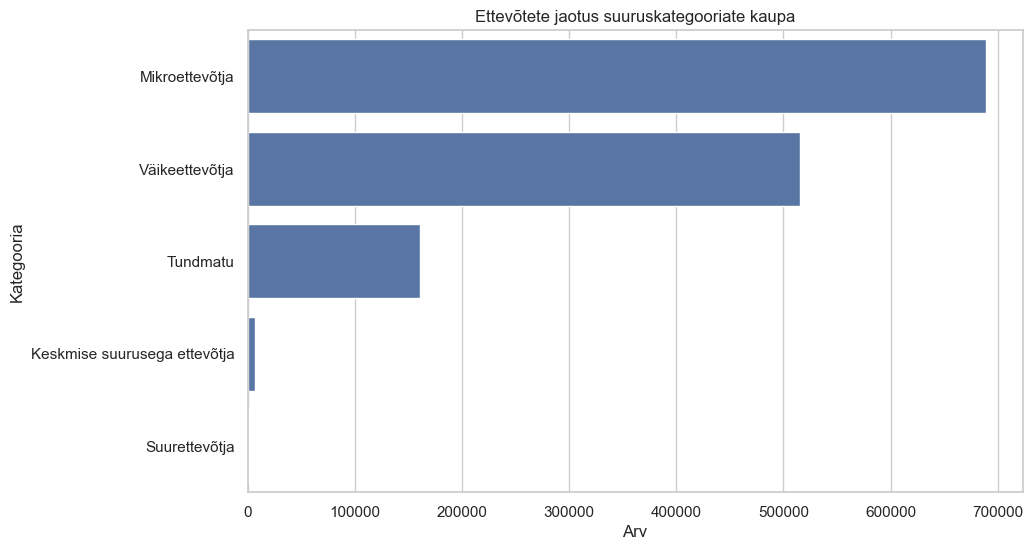

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seadistame graafikute stiili
sns.set_theme(style="whitegrid")

# 1. Ettevõtete jaotus suuruskategooria järgi
plt.figure(figsize=(10, 6))
sns.countplot(data=df_cleaned, y='minimaalne kategooria andmete alusel', order=df_cleaned['minimaalne kategooria andmete alusel'].value_counts().index)
plt.title('Ettevõtete jaotus suuruskategooriate kaupa')
plt.xlabel('Arv')
plt.ylabel('Kategooria')
plt.show()

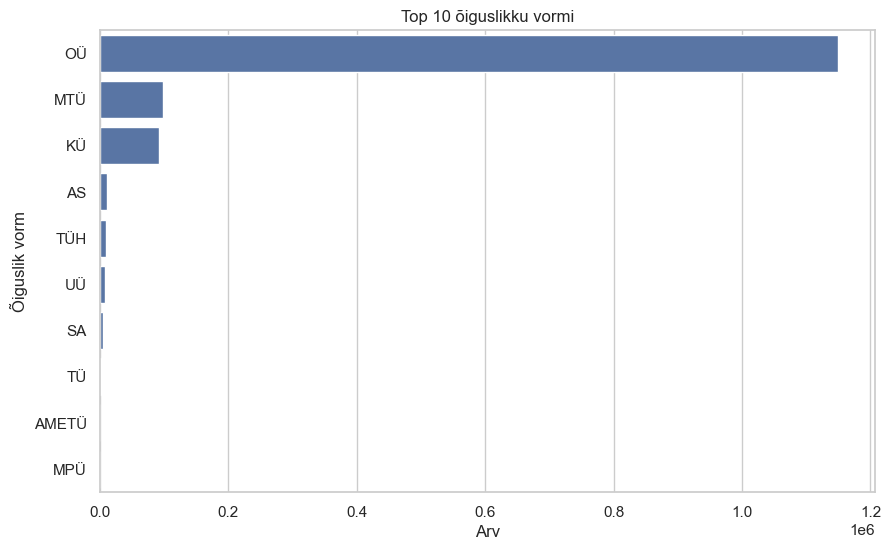

In [13]:
# 2. Õiguslike vormide jaotus (võtame 10 kõige levinumat)
plt.figure(figsize=(10, 6))
top_vormid = df_cleaned['õiguslik vorm'].value_counts().head(10)
sns.barplot(x=top_vormid.values, y=top_vormid.index)
plt.title('Top 10 õiguslikku vormi')
plt.xlabel('Arv')
plt.ylabel('Õiguslik vorm')
plt.show()

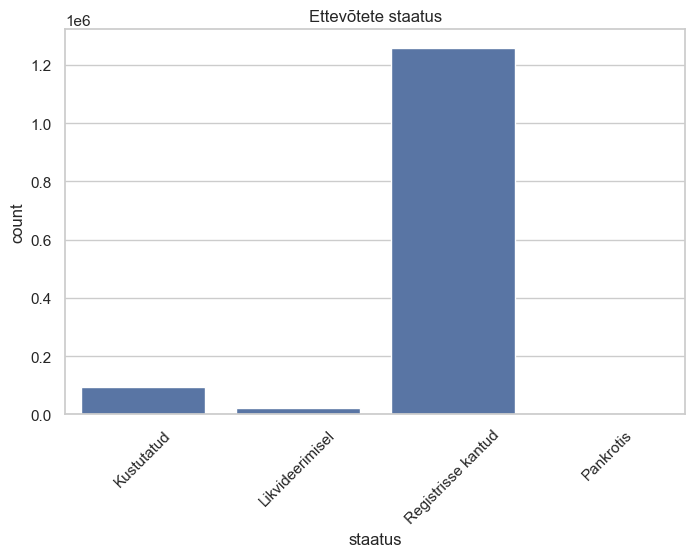

In [17]:
# 3. Kustutatud vs aktiivsete ettevõtete jaotus
plt.figure(figsize=(8, 5))
sns.countplot(data=df_cleaned, x='staatus')
plt.title('Ettevõtete staatus')
plt.xticks(rotation=45)
plt.show()

## Hüpoteeside kontroll

Püstitame kaks statistilist hüpoteesi, mida andmetel testida:

**Hüpotees 1:** "Väikeettevõtjad" (minimaalne kategooria andmete alusel) on keskmiselt suurema varade (Assets) mahuga kui "Mikroettevõtjad".
*   H0 (nullhüpotees): Keskmiste varade mahus ei ole erinevust.
*   H1 (alternatiivne hüpotees): Väikeettevõtjatel on suurem keskmine varade maht.

**Hüpotees 2:** Osaühingute (OÜ) ja Aktsiaseltside (AS) keskmine töötajate arv erineb statistiliselt olulisel määral.
*   H0: Keskmine töötajate arv on sama.
*   H1: Keskmine töötajate arv on erinev.

In [15]:
from scipy import stats

# Hüpotees 1: Kas "Väikeettevõtja" vs "Mikroettevõtja" varad (Assets) on erinevad?
# Eemaldame 0-varadega ja NaN varadega ettevõtted täpsemaks pildiks ning piirame outliers.
df_assets = df_cleaned[(df_cleaned['Assets'] > 0) & (df_cleaned['Assets'] < df_cleaned['Assets'].quantile(0.99))]

mikro = df_assets[df_assets['minimaalne kategooria andmete alusel'] == 'Mikroettevõtja']['Assets']
vaike = df_assets[df_assets['minimaalne kategooria andmete alusel'] == 'Väikeettevõtja']['Assets']

# T-test sõltumatutele valimitele (eeldatavasti ei ole normaaljaotuses, aga suure valimi puhul CLT pädeb)
t_stat_1, p_val_1 = stats.ttest_ind(vaike, mikro, equal_var=False)

print(f"--- Hüpotees 1 ---")
print(f"Mikroettevõtja keskmine vara: {mikro.mean():.2f}")
print(f"Väikeettevõtja keskmine vara: {vaike.mean():.2f}")
print(f"T-statistik: {t_stat_1:.2f}, p-väärtus: {p_val_1:.5e}")
if p_val_1 < 0.05:
    print("Tulemus on statistiliselt oluline: lükkame H0 ümber, väikeettevõtjatel on oluliselt suuremad varad.")
else:
    print("Tulemus ei ole statistiliselt oluline.")

--- Hüpotees 1 ---
Mikroettevõtja keskmine vara: 71957.35
Väikeettevõtja keskmine vara: 373115.83
T-statistik: 242.09, p-väärtus: 0.00000e+00
Tulemus on statistiliselt oluline: lükkame H0 ümber, väikeettevõtjatel on oluliselt suuremad varad.


In [19]:
# Hüpotees 2: Osaühingute (OÜ) ja Aktsiaseltside (AS) keskmine töötajate arv erineb
employees_col = 'Töötajate_arv'
df_emp = df_cleaned[df_cleaned[employees_col] > 0]

ou_emp = df_emp[df_emp['õiguslik vorm'] == 'OÜ'][employees_col]
as_emp = df_emp[df_emp['õiguslik vorm'] == 'AS'][employees_col]

t_stat_2, p_val_2 = stats.ttest_ind(as_emp, ou_emp, equal_var=False)

print(f"--- Hüpotees 2 ---")
print(f"OÜ keskmine töötajate arv: {ou_emp.mean():.2f}")
print(f"AS keskmine töötajate arv: {as_emp.mean():.2f}")
print(f"T-statistik: {t_stat_2:.2f}, p-väärtus: {p_val_2:.5e}")
if p_val_2 < 0.05:
    print("Tulemus on statistiliselt oluline: Aktsiaseltsidel on keskmiselt oluliselt rohkem töötajaid kui Osaühingutel.")
else:
    print("Tulemus ei ole statistiliselt oluline.")

--- Hüpotees 2 ---
OÜ keskmine töötajate arv: 4.08
AS keskmine töötajate arv: 65.77
T-statistik: 31.14, p-väärtus: 4.38017e-202
Tulemus on statistiliselt oluline: Aktsiaseltsidel on keskmiselt oluliselt rohkem töötajaid kui Osaühingutel.


## Andmete salvestamine mudelite jaoks

Salvestame puhastatud andmestiku `df_cleaned` faili, et seda saaks kasutada eraldi märkmikus (`Predictive_Modelling.ipynb`).

In [23]:
# Salvestame puhastatud andmestiku parquet formaadis
df_cleaned.to_parquet('data/cleaned_reports_for_modeling.parquet', index=False)
print("Puhastatud andmestik salvestatud: data/cleaned_reports_for_modeling.parquet")

Puhastatud andmestik salvestatud: data/cleaned_reports_for_modeling.parquet
